# 🌾 Crop Yield Prediction Model
## Code4Food Security Fellowship — Capstone Project
**Author:** Justina Ama Boadiwaa Asante  
**Fellowship:** Blossom Academy | WFP Ghana | KOICA  
**Date:** April 2026

---

### Project Overview
This notebook builds a machine learning pipeline to **predict crop yield (tons/ha)** from agronomic and environmental features including soil type, rainfall, temperature, fertilizer use, irrigation method, and planting density.

The workflow follows a rigorous data science process:
1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Feature Engineering
4. Model Training — Random Forest & Gradient Boosting
5. Model Evaluation & Comparison
6. Feature Importance Analysis
7. Conclusions & Recommendations

---


## 1. Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
sns.set_palette('Set2')
print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


## 2. Load & Inspect Data

In [11]:
df = pd.read_csv('crop_yield_dataset.csv')
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(10)

Dataset shape: 10,000 rows × 13 columns


,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop,Yield_ton_per_ha
0,Maize,Region_C,Sandy,7.01,1485.4,19.7,40.3,105.1,Drip,10.2,23.2,Rice,101.48
1,Barley,Region_D,Loam,5.79,399.4,29.1,55.4,221.8,Sprinkler,35.5,7.4,Barley,127.39
2,Rice,Region_C,Clay,7.24,980.9,30.5,74.4,61.2,Sprinkler,40.0,5.1,Wheat,68.99
3,Maize,Region_D,Loam,6.79,1054.3,26.4,62.0,257.8,Drip,42.7,23.7,NaN,169.06
4,Maize,Region_D,Sandy,5.96,744.6,20.4,70.9,195.8,Drip,25.5,15.6,Maize,118.71
5,Barley,Region_C,Sandy,5.82,817.5,23.1,47.6,64.6,NaN,16.4,16.2,Maize,58.85
6,Rice,Region_B,Sandy,6.76,1358.2,16.9,31.9,267.9,Sprinkler,38.6,23.6,Rice,173.44
7,Rice,Region_D,Sandy,7.30,1038.9,34.1,31.7,269.4,Sprinkler,16.0,19.0,Barley,170.05
8,Maize,Region_C,Loam,6.94,846.1,32.4,86.6,263.2,NaN,7.4,21.5,Wheat,162.20
9,Wheat,Region_A,Clay,6.20,366.9,16.3,86.7,243.6,Sprinkler,41.7,20.4,Wheat,141.67


In [12]:
print("=" * 55)
print("DATASET INFORMATION")
print("=" * 55)
df.info()


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Crop                10000 non-null  object 
 1   Region              10000 non-null  object 
 2   Soil_Type           10000 non-null  object 
 3   Soil_pH             10000 non-null  float64
 4   Rainfall_mm         10000 non-null  float64
 5   Temperature_C       10000 non-null  float64
 6   Humidity_pct        10000 non-null  float64
 7   Fertilizer_Used_kg  10000 non-null  float64
 8   Irrigation          7462 non-null   object 
 9   Pesticides_Used_kg  10000 non-null  float64
 10  Planting_Density    10000 non-null  float64
 11  Previous_Crop       7969 non-null   object 
 12  Yield_ton_per_ha    10000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1015.8+ KB


In [13]:
# Rename regions to Ghana-specific names
region_mapping = {
    'Region_A': 'Northern Region',
    'Region_B': 'Eastern Region',
    'Region_C': 'Western Region',
    'Region_D': 'Savannah Region'
}

df['Region'] = df['Region'].map(region_mapping)

# Verify
print(df['Region'].value_counts())

Region
Northern Region    2561
Eastern Region     2501
Savannah Region    2492
Western Region     2446
Name: count, dtype: int64


In [14]:
# Rename crops to Ghanaian grown crops
crop_mapping = {
    'Maize': 'Maize',
    'Rice': 'Rice',
    'Barley': 'Cassava',
    'Wheat': 'Cocoa'
}

df['Crop'] = df['Crop'].map(crop_mapping)

# Verify
print(df['Crop'].value_counts())


Crop
Rice       2536
Cassava    2501
Cocoa      2486
Maize      2477
Name: count, dtype: int64


In [15]:
# Rename crops to Ghanaian grown crops
Previous_mapping = {
    'Maize': 'Maize',
    'Rice': 'Rice',
    'Barley': 'Cassava',
    'Wheat': 'Cocoa'
}

df['Previous_Crop'] = df['Previous_Crop'].map(Previous_mapping)

# Verify
print(df['Previous_Crop'].value_counts())


Previous_Crop
Rice       2072
Maize      1972
Cassava    1965
Cocoa      1960
Name: count, dtype: int64


In [16]:
print("=" * 55)
print("MISSING VALUES SUMMARY")
print("=" * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]


MISSING VALUES SUMMARY


,Missing Count,Missing %
Irrigation,2538,25.38
Previous_Crop,2031,20.31


In [17]:
print("=" * 55)
print("DESCRIPTIVE STATISTICS — NUMERIC FEATURES")
print("=" * 55)
df.describe().round(2)


DESCRIPTIVE STATISTICS — NUMERIC FEATURES


,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Pesticides_Used_kg,Planting_Density,Yield_ton_per_ha
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,6.52,843.66,24.98,60.05,175.08,25.06,15.00,117.89
std,0.57,373.67,5.79,17.32,71.96,14.35,5.83,37.97
min,5.50,200.00,15.00,30.00,50.00,0.00,5.00,28.45
25%,6.02,518.00,20.00,45.10,113.30,12.60,9.90,87.14
50%,6.52,845.30,24.90,60.20,175.00,25.30,15.00,117.71
75%,7.01,1161.85,30.10,75.10,237.90,37.50,20.10,149.15
max,7.50,1499.70,35.00,90.00,300.00,50.00,25.00,207.21


In [18]:
print("Categorical feature value counts:")
for col in ['Crop', 'Region', 'Soil_Type', 'Irrigation', 'Previous_Crop']:
    print(f"\n{col}: {df[col].value_counts().to_dict()}")


Categorical feature value counts:

Crop: {'Rice': 2536, 'Cassava': 2501, 'Cocoa': 2486, 'Maize': 2477}

Region: {'Northern Region': 2561, 'Eastern Region': 2501, 'Savannah Region': 2492, 'Western Region': 2446}

Soil_Type: {'Loam': 3388, 'Sandy': 3328, 'Clay': 3284}

Irrigation: {'Flood': 2530, 'Drip': 2472, 'Sprinkler': 2460}

Previous_Crop: {'Rice': 2072, 'Maize': 1972, 'Cassava': 1965, 'Cocoa': 1960}


## 3. Exploratory Data Analysis (EDA)

EDA helps us understand:
- How yield is distributed across crop types and regions
- Relationships between climate/agronomic variables and yield
- Correlations between features
- Outliers and data quality issues


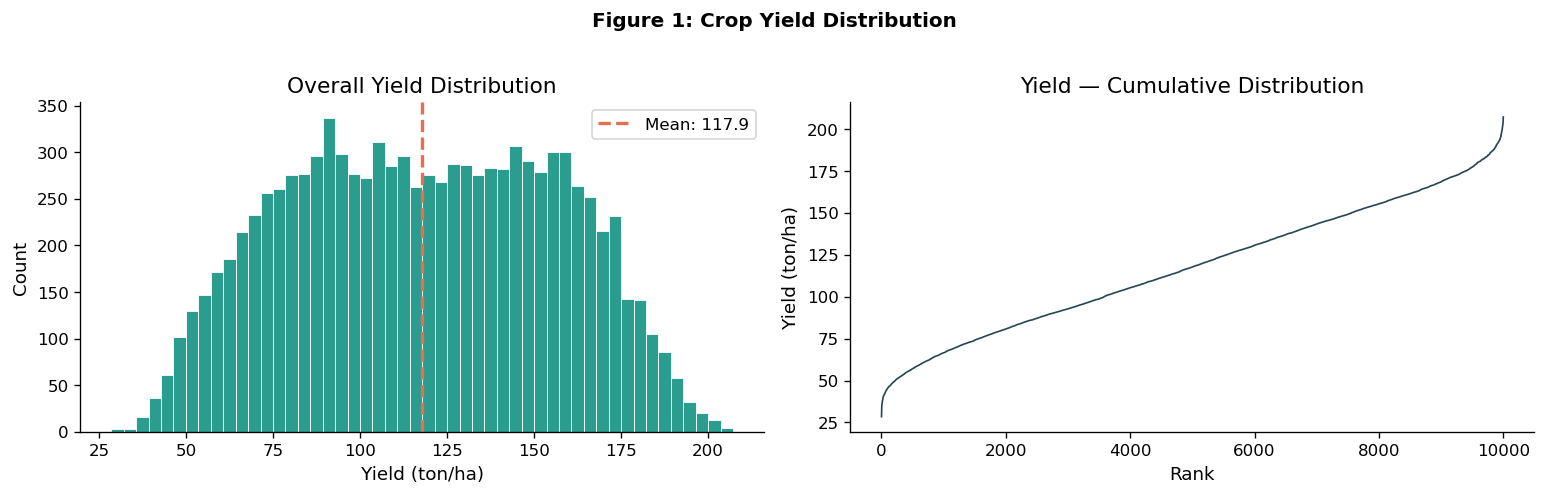

Yield stats → Mean: 117.89 | Std: 37.97 | Min: 28.45 | Max: 207.21


In [19]:
# 3.1 Yield Distribution Overall
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Yield_ton_per_ha'], bins=50, color='#2a9d8f', edgecolor='white', linewidth=0.5)
axes[0].set_title('Overall Yield Distribution')
axes[0].set_xlabel('Yield (ton/ha)')
axes[0].set_ylabel('Count')
mean_yield = df['Yield_ton_per_ha'].mean()
axes[0].axvline(mean_yield, color='#e76f51', linestyle='--', linewidth=2, label=f'Mean: {mean_yield:.1f}')
axes[0].legend()

# Q-Q style: sorted yield
sorted_yields = np.sort(df['Yield_ton_per_ha'])
axes[1].plot(np.arange(len(sorted_yields)), sorted_yields, color='#264653', linewidth=1)
axes[1].set_title('Yield — Cumulative Distribution')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Yield (ton/ha)')

plt.suptitle('Figure 1: Crop Yield Distribution', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_yield_distribution.png', bbox_inches='tight')
plt.show()
print(f"Yield stats → Mean: {df['Yield_ton_per_ha'].mean():.2f} | Std: {df['Yield_ton_per_ha'].std():.2f} | Min: {df['Yield_ton_per_ha'].min():.2f} | Max: {df['Yield_ton_per_ha'].max():.2f}")


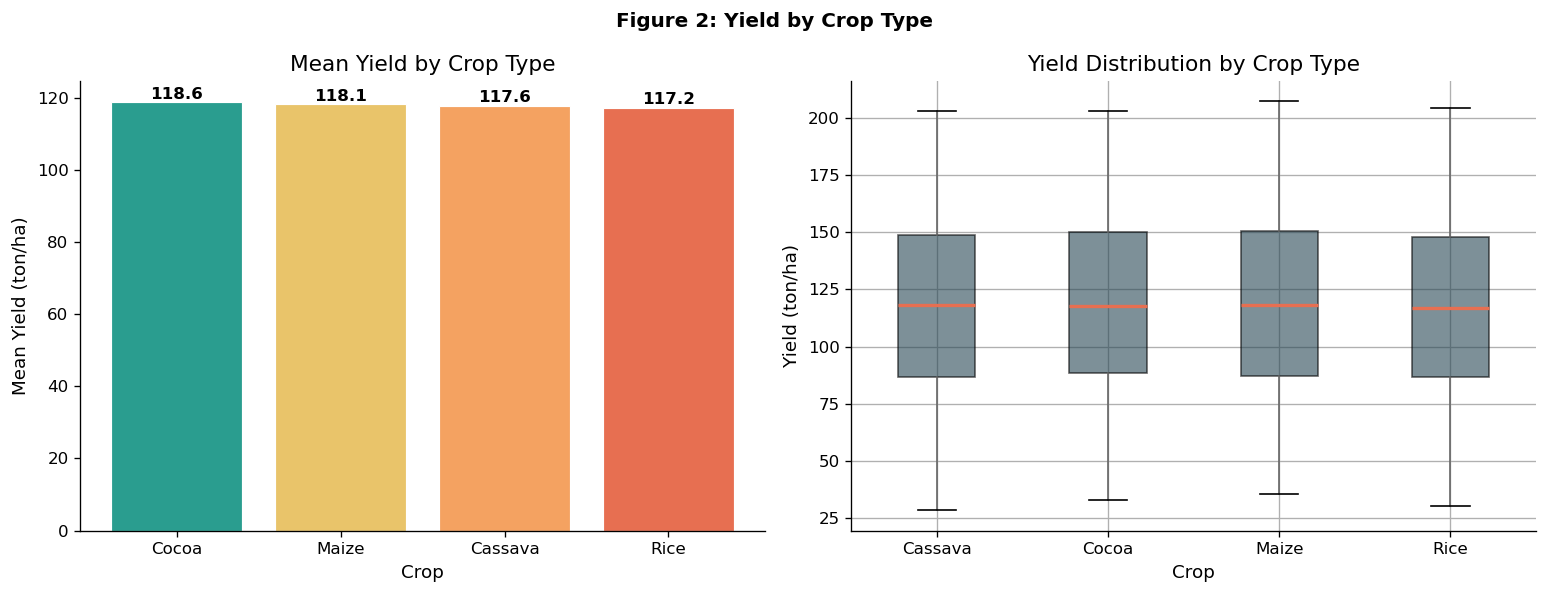

In [20]:
# 3.2 Yield by Crop Type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

crop_means = df.groupby('Crop')['Yield_ton_per_ha'].mean().sort_values(ascending=False)
colors = ['#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']

axes[0].bar(crop_means.index, crop_means.values, color=colors, edgecolor='white', linewidth=0.7)
axes[0].set_title('Mean Yield by Crop Type')
axes[0].set_xlabel('Crop')
axes[0].set_ylabel('Mean Yield (ton/ha)')
for i, (crop, val) in enumerate(crop_means.items()):
    axes[0].text(i, val + 1, f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

df.boxplot(column='Yield_ton_per_ha', by='Crop', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#264653', alpha=0.6),
           medianprops=dict(color='#e76f51', linewidth=2))
axes[1].set_title('Yield Distribution by Crop Type')
axes[1].set_xlabel('Crop')
axes[1].set_ylabel('Yield (ton/ha)')
plt.suptitle('')

plt.suptitle('Figure 2: Yield by Crop Type', fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_yield_by_crop.png', bbox_inches='tight')
plt.show()


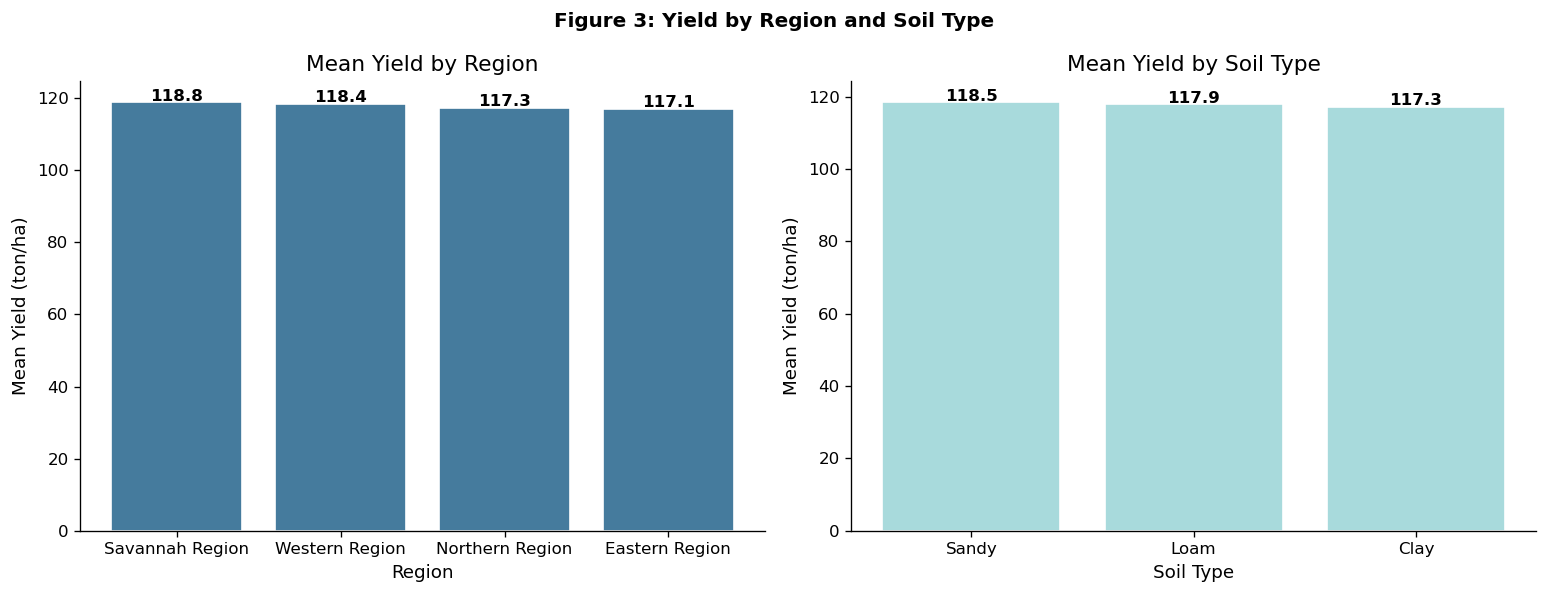

In [21]:
# 3.3 Yield by Region and Soil Type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

region_means = df.groupby('Region')['Yield_ton_per_ha'].mean().sort_values(ascending=False)
axes[0].bar(region_means.index, region_means.values, color='#457b9d', edgecolor='white')
axes[0].set_title('Mean Yield by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Mean Yield (ton/ha)')
for i, (reg, val) in enumerate(region_means.items()):
    axes[0].text(i, val + 0.5, f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

soil_means = df.groupby('Soil_Type')['Yield_ton_per_ha'].mean().sort_values(ascending=False)
axes[1].bar(soil_means.index, soil_means.values, color='#a8dadc', edgecolor='white')
axes[1].set_title('Mean Yield by Soil Type')
axes[1].set_xlabel('Soil Type')
axes[1].set_ylabel('Mean Yield (ton/ha)')
for i, (soil, val) in enumerate(soil_means.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Figure 3: Yield by Region and Soil Type', fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_yield_region_soil.png', bbox_inches='tight')
plt.show()


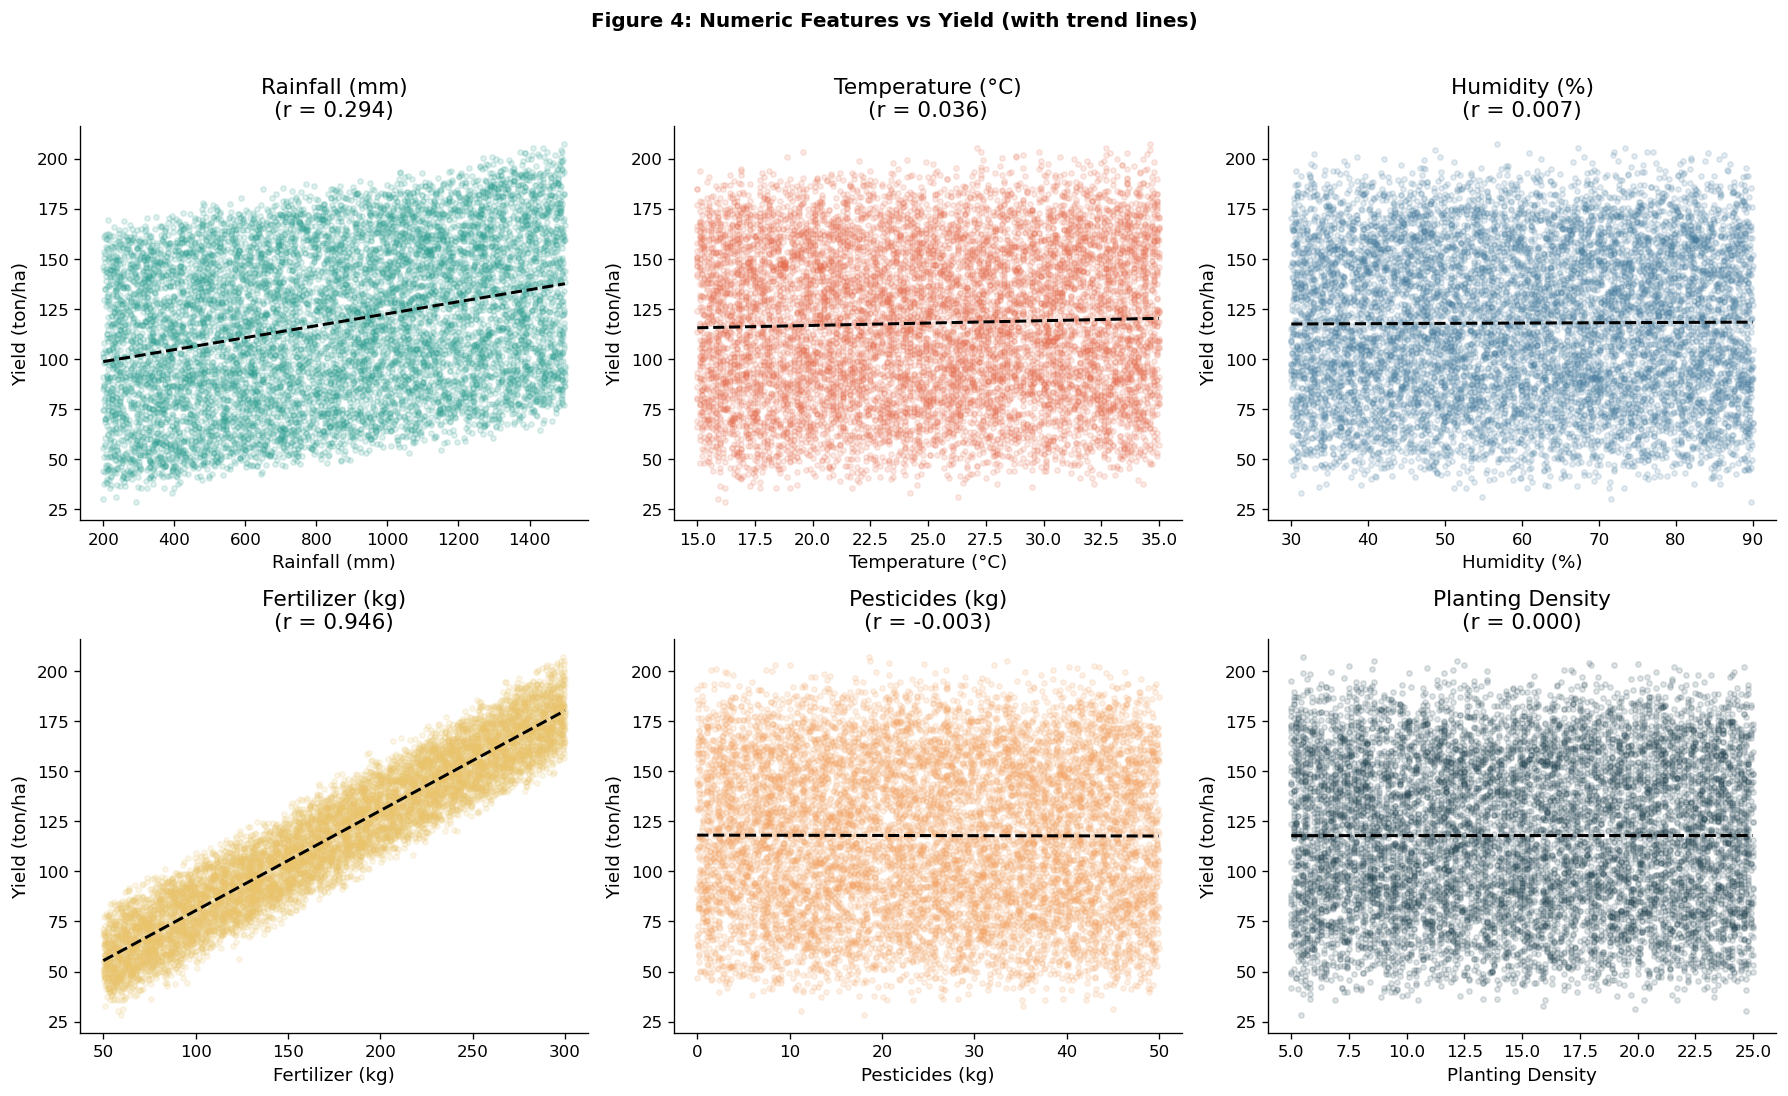

In [22]:
# 3.4 Climate Variables vs Yield — Scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

numeric_features = ['Rainfall_mm', 'Temperature_C', 'Humidity_pct',
                    'Fertilizer_Used_kg', 'Pesticides_Used_kg', 'Planting_Density']
feature_labels  = ['Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)',
                   'Fertilizer (kg)', 'Pesticides (kg)', 'Planting Density']
colors_scatter  = ['#2a9d8f', '#e76f51', '#457b9d', '#e9c46a', '#f4a261', '#264653']

for i, (feat, label, col) in enumerate(zip(numeric_features, feature_labels, colors_scatter)):
    axes[i].scatter(df[feat], df['Yield_ton_per_ha'], alpha=0.15, s=10, color=col)
    # trend line
    z = np.polyfit(df[feat], df['Yield_ton_per_ha'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 300)
    axes[i].plot(x_line, p(x_line), color='black', linewidth=1.8, linestyle='--')
    corr = df[feat].corr(df['Yield_ton_per_ha'])
    axes[i].set_title(f'{label}\n(r = {corr:.3f})')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Yield (ton/ha)')

plt.suptitle('Figure 4: Numeric Features vs Yield (with trend lines)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_scatter_features_yield.png', bbox_inches='tight')
plt.show()


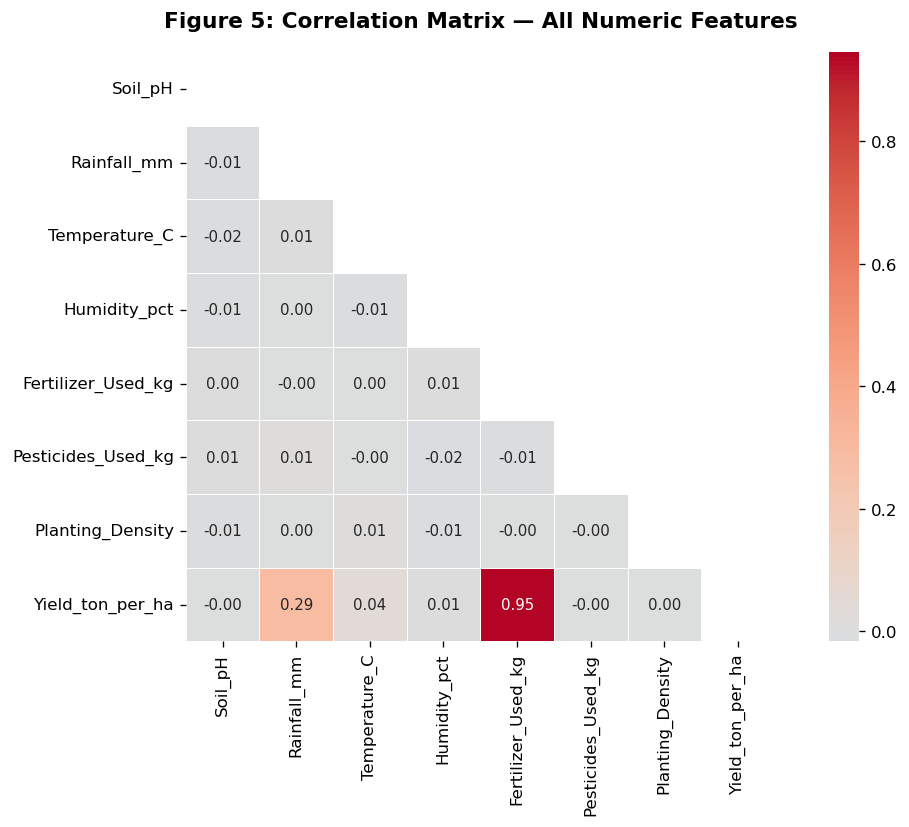

In [23]:
# 3.5 Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix  = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Figure 5: Correlation Matrix — All Numeric Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', bbox_inches='tight')
plt.show()


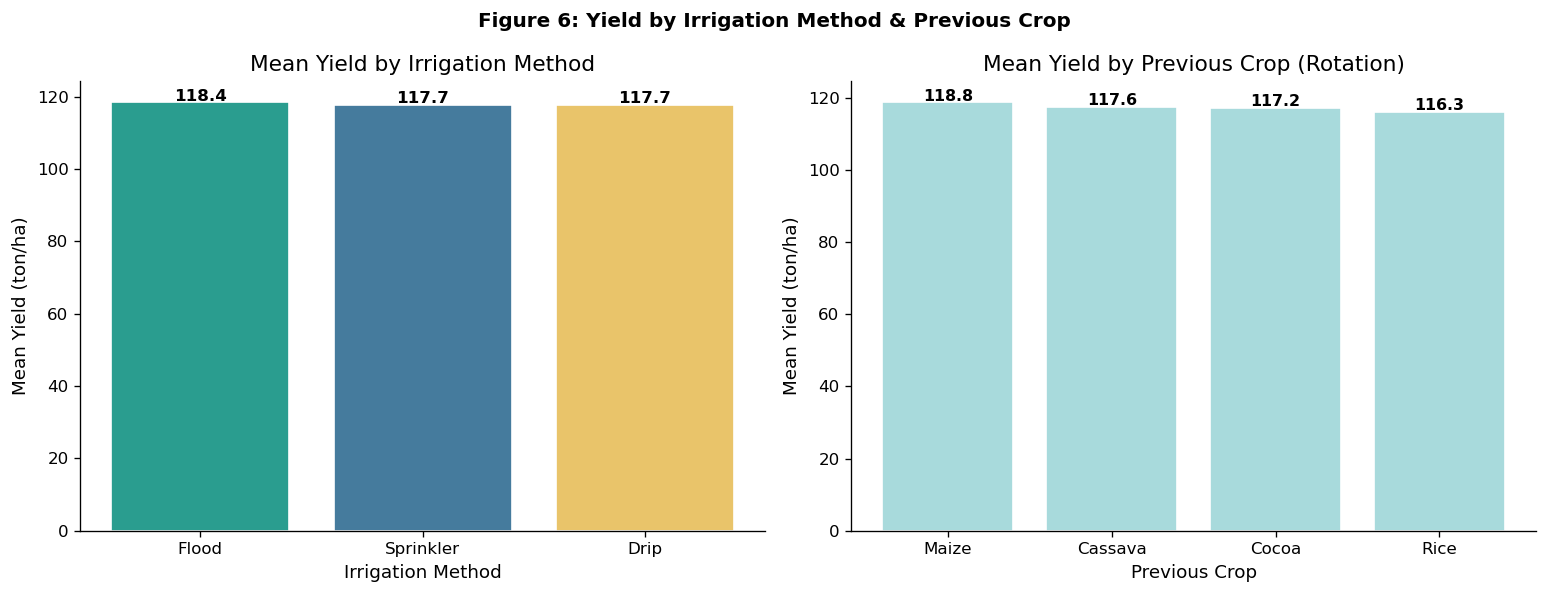

In [24]:
# 3.6 Yield by Irrigation Method
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

irr_means = df.groupby('Irrigation')['Yield_ton_per_ha'].mean().sort_values(ascending=False)
axes[0].bar(irr_means.index, irr_means.values, color=['#2a9d8f','#457b9d','#e9c46a','#e76f51'], edgecolor='white')
axes[0].set_title('Mean Yield by Irrigation Method')
axes[0].set_xlabel('Irrigation Method')
axes[0].set_ylabel('Mean Yield (ton/ha)')
for i, (irr, val) in enumerate(irr_means.items()):
    axes[0].text(i, val + 0.5, f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

prev_means = df.groupby('Previous_Crop')['Yield_ton_per_ha'].mean().sort_values(ascending=False)
axes[1].bar(prev_means.index, prev_means.values, color='#a8dadc', edgecolor='white')
axes[1].set_title('Mean Yield by Previous Crop (Rotation)')
axes[1].set_xlabel('Previous Crop')
axes[1].set_ylabel('Mean Yield (ton/ha)')
for i, (prev, val) in enumerate(prev_means.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}', ha='center', fontsize=9.5, fontweight='bold')

plt.suptitle('Figure 6: Yield by Irrigation Method & Previous Crop', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_yield_irrigation_rotation.png', bbox_inches='tight')
plt.show()


## 4. Data Preprocessing & Feature Engineering

Steps:
- Handle missing values (Irrigation → mode imputation; Previous_Crop → 'None')
- Encode categorical variables using Label Encoding
- Scale numeric features using StandardScaler
- Create interaction feature: Rainfall × Fertilizer efficiency index


In [25]:
# 4.1 Handle Missing Values
df_clean = df.copy()

# Irrigation: fill with mode (most common method)
irrigation_mode = df_clean['Irrigation'].mode()[0]
df_clean['Irrigation'].fillna(irrigation_mode, inplace=True)

# Previous_Crop: fill with 'None' (no prior crop — legitimate agronomic state)
df_clean['Previous_Crop'].fillna('None', inplace=True)

print(f"Missing values after imputation: {df_clean.isnull().sum().sum()}")
print(f"Irrigation mode used: {irrigation_mode}")


Missing values after imputation: 0
Irrigation mode used: Flood


In [26]:
# 4.2 Feature Engineering
# Interaction: Fertilizer Efficiency Index = Fertilizer / (Rainfall + 1) 
# captures whether fertilizer is being applied in proportion to water availability
df_clean['Fertilizer_Efficiency'] = df_clean['Fertilizer_Used_kg'] / (df_clean['Rainfall_mm'] + 1)

# Temperature-Humidity stress index (heat + humidity combined stress)
df_clean['Heat_Humidity_Index'] = df_clean['Temperature_C'] * df_clean['Humidity_pct'] / 100

print("✅ Feature engineering complete")
print(f"New features: Fertilizer_Efficiency, Heat_Humidity_Index")
print(f"Total features now: {df_clean.shape[1] - 1} (excl. target)")


✅ Feature engineering complete
New features: Fertilizer_Efficiency, Heat_Humidity_Index
Total features now: 14 (excl. target)


In [27]:
# 4.3 Encode Categorical Variables
le_dict = {}
cat_cols = ['Crop', 'Region', 'Soil_Type', 'Irrigation', 'Previous_Crop']

df_encoded = df_clean.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Crop: {'Cassava': np.int64(0), 'Cocoa': np.int64(1), 'Maize': np.int64(2), 'Rice': np.int64(3)}
Region: {'Eastern Region': np.int64(0), 'Northern Region': np.int64(1), 'Savannah Region': np.int64(2), 'Western Region': np.int64(3)}
Soil_Type: {'Clay': np.int64(0), 'Loam': np.int64(1), 'Sandy': np.int64(2)}
Irrigation: {'Drip': np.int64(0), 'Flood': np.int64(1), 'Sprinkler': np.int64(2)}
Previous_Crop: {'Cassava': np.int64(0), 'Cocoa': np.int64(1), 'Maize': np.int64(2), 'None': np.int64(3), 'Rice': np.int64(4)}


In [28]:
# 4.4 Define Features and Target
feature_cols = [c for c in df_encoded.columns if c != 'Yield_ton_per_ha']
X = df_encoded[feature_cols]
y = df_encoded['Yield_ton_per_ha']

# 4.5 Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4.6 Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Features     : {X_train.shape[1]}")


Training set : 8,000 samples
Test set     : 2,000 samples
Features     : 14


## 5. Model Training

We train and compare **three models**:
| Model | Type | Strength |
|-------|------|----------|
| Linear Regression | Baseline | Simple, interpretable |
| Random Forest | Ensemble (Bagging) | Robust, handles non-linearity |
| Gradient Boosting | Ensemble (Boosting) | High accuracy, sequential error correction |


In [29]:
# 5.1 Define Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.85,
        min_samples_split=5,
        random_state=42
    )
}

print("✅ Models defined:")
for name, model in models.items():
    print(f"   • {name}")


✅ Models defined:
   • Linear Regression
   • Random Forest
   • Gradient Boosting


In [30]:
# 5.2 Train All Models & Evaluate
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, y_pred))
    mae   = mean_absolute_error(y_te, y_pred)
    r2    = r2_score(y_te, y_pred)
    mape  = mean_absolute_percentage_error(y_te, y_pred) * 100
    return {'Model': name, 'RMSE': round(rmse,3), 'MAE': round(mae,3),
            'R2': round(r2,4), 'MAPE_%': round(mape,2)}, y_pred

results = []
predictions = {}

# Linear Regression on scaled data
res, preds = evaluate_model('Linear Regression', models['Linear Regression'],
                             X_train_scaled, y_train, X_test_scaled, y_test)
results.append(res); predictions['Linear Regression'] = preds

# Tree models on unscaled data (trees don't need scaling)
for name in ['Random Forest', 'Gradient Boosting']:
    res, preds = evaluate_model(name, models[name], X_train, y_train, X_test, y_test)
    results.append(res); predictions[name] = preds

results_df = pd.DataFrame(results).set_index('Model')
print("=" * 60)
print("MODEL PERFORMANCE ON TEST SET (n=2,000)")
print("=" * 60)
print(results_df.to_string())
print("\nBest model by R²:", results_df['R2'].idxmax())
print("Best model by RMSE:", results_df['RMSE'].idxmin())


MODEL PERFORMANCE ON TEST SET (n=2,000)
                    RMSE    MAE      R2  MAPE_%
Model                                          
Linear Regression  5.079  4.075  0.9821    3.99
Random Forest      5.356  4.296  0.9801    4.19
Gradient Boosting  5.262  4.238  0.9808    4.14

Best model by R²: Linear Regression
Best model by RMSE: Linear Regression


In [31]:
# 5.3 Cross-Validation — Best Model Robustness Check
best_model_name = results_df['R2'].idxmax()
best_model = models[best_model_name]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2   = cross_val_score(best_model, X, y, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(best_model, X, y, cv=kf, scoring='neg_mean_squared_error'))

print(f"5-Fold Cross-Validation — {best_model_name}")
print(f"{'=' * 45}")
print(f"R²   scores per fold : {[round(v,4) for v in cv_r2]}")
print(f"RMSE scores per fold : {[round(v,3) for v in cv_rmse]}")
print(f"{'=' * 45}")
print(f"Mean R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"Mean RMSE : {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")


5-Fold Cross-Validation — Linear Regression
R²   scores per fold : [np.float64(0.9821), np.float64(0.9827), np.float64(0.9826), np.float64(0.9826), np.float64(0.9823)]
RMSE scores per fold : [np.float64(5.079), np.float64(5.013), np.float64(5.122), np.float64(4.949), np.float64(4.974)]
Mean R²   : 0.9825 ± 0.0002
Mean RMSE : 5.027 ± 0.064


## 6. Model Evaluation & Visualisation

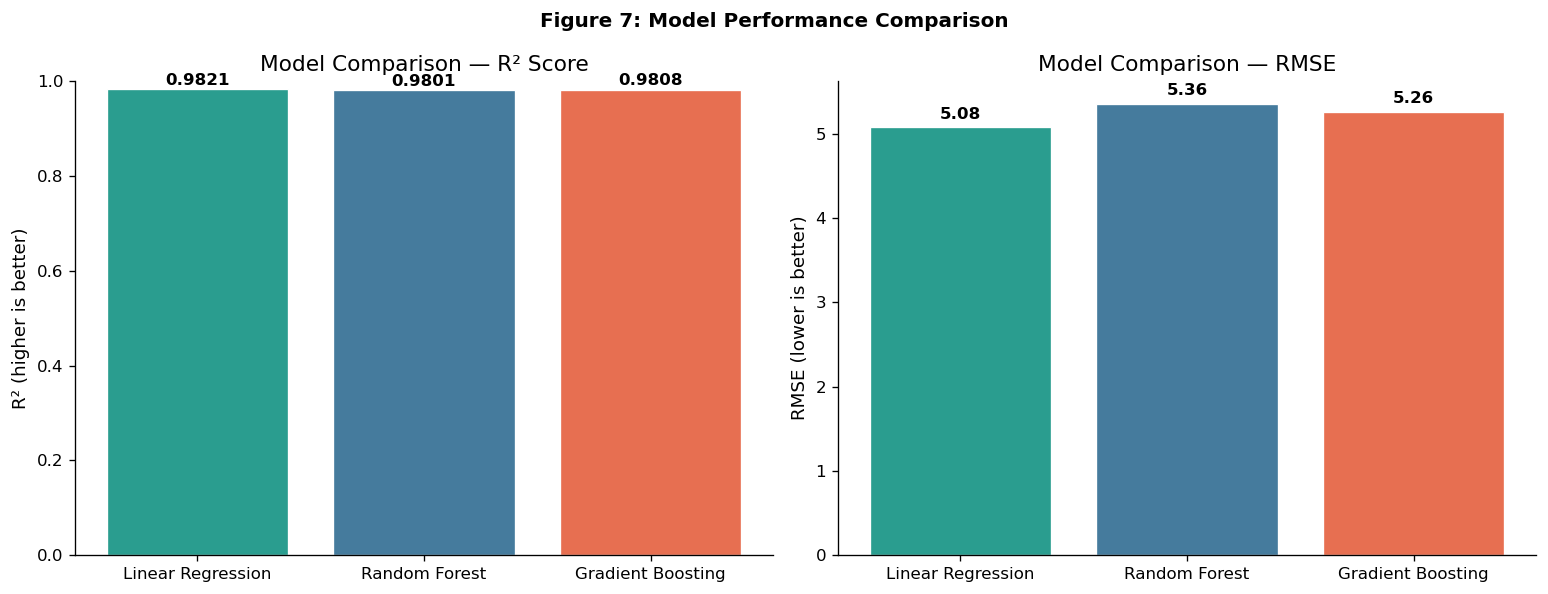

In [32]:
# 6.1 Performance Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metric_colors = ['#2a9d8f', '#457b9d', '#e76f51']
model_names   = results_df.index.tolist()

# R2
r2_vals = results_df['R2'].values
bars = axes[0].bar(model_names, r2_vals, color=metric_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Model Comparison — R² Score')
axes[0].set_ylabel('R² (higher is better)')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# RMSE
rmse_vals = results_df['RMSE'].values
bars2 = axes[1].bar(model_names, rmse_vals, color=metric_colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Model Comparison — RMSE')
axes[1].set_ylabel('RMSE (lower is better)')
for bar, val in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Figure 7: Model Performance Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_model_comparison.png', bbox_inches='tight')
plt.show()


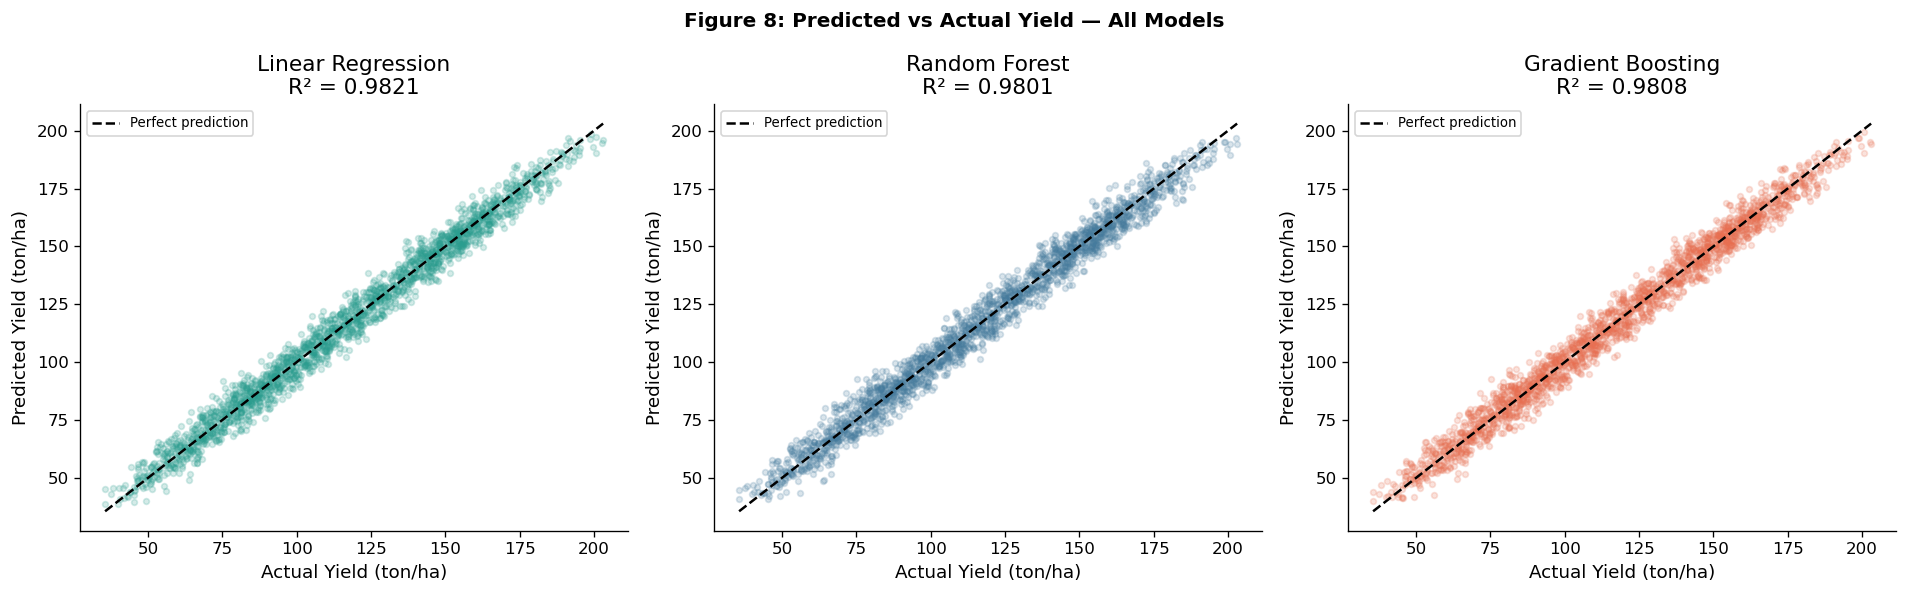

In [33]:
# 6.2 Predicted vs Actual — All Models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_pred = ['#2a9d8f', '#457b9d', '#e76f51']

for ax, (mname, preds), col in zip(axes, predictions.items(), colors_pred):
    ax.scatter(y_test, preds, alpha=0.2, s=12, color=col)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')
    r2 = r2_score(y_test, preds)
    ax.set_title(f'{mname}\nR² = {r2:.4f}')
    ax.set_xlabel('Actual Yield (ton/ha)')
    ax.set_ylabel('Predicted Yield (ton/ha)')
    ax.legend(fontsize=8)

plt.suptitle('Figure 8: Predicted vs Actual Yield — All Models', fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_pred_vs_actual.png', bbox_inches='tight')
plt.show()


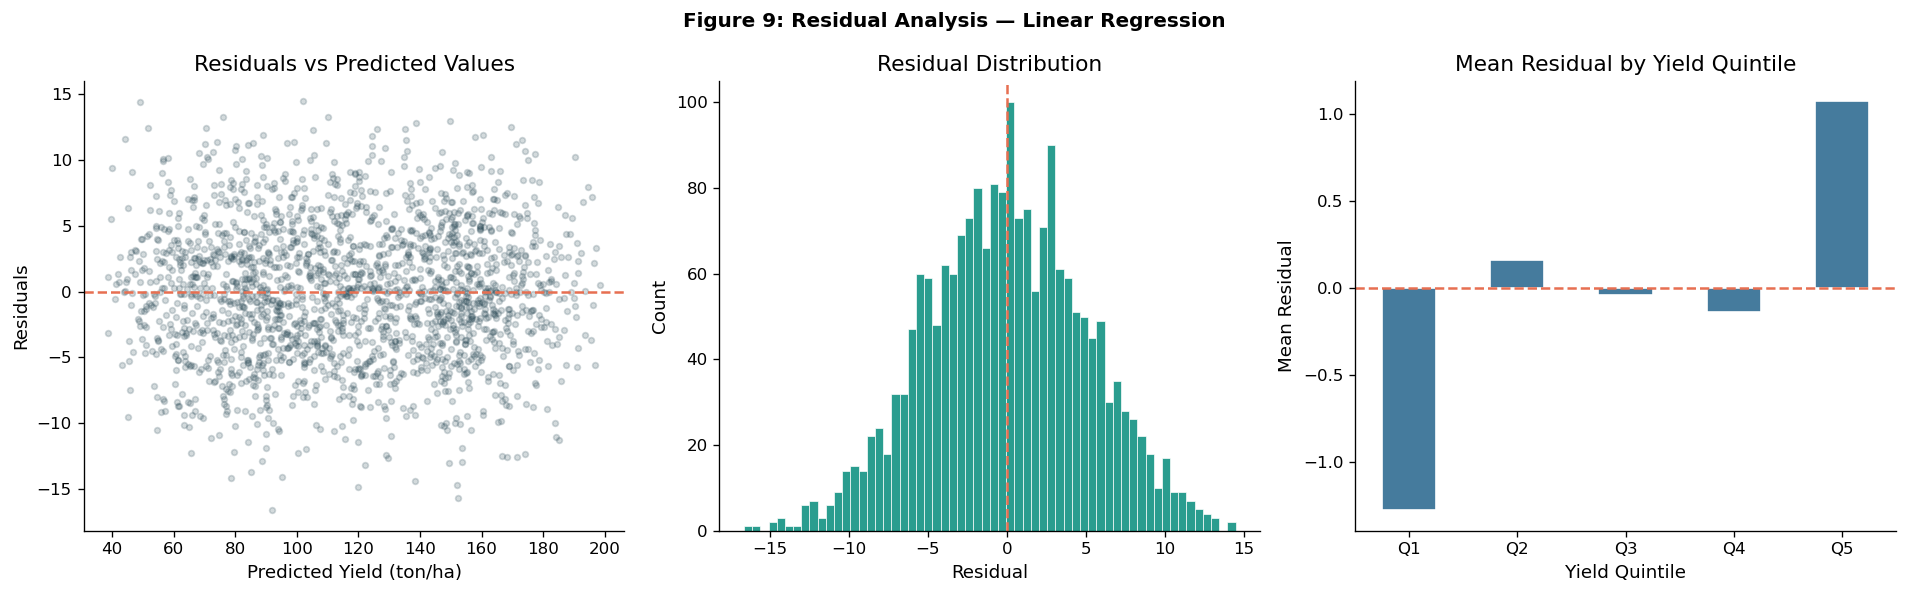

In [34]:
# 6.3 Residual Analysis — Best Model
best_preds    = predictions[best_model_name]
residuals     = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals vs Predicted
axes[0].scatter(best_preds, residuals, alpha=0.2, s=12, color='#264653')
axes[0].axhline(0, color='#e76f51', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Yield (ton/ha)')
axes[0].set_ylabel('Residuals')

# Residual distribution
axes[1].hist(residuals, bins=60, color='#2a9d8f', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='#e76f51', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')

# Residuals by actual range (binned)
bins = pd.qcut(y_test, q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
resid_by_bin = pd.DataFrame({'bin': bins.values, 'residual': residuals})
resid_by_bin.groupby('bin')['residual'].mean().plot(kind='bar', ax=axes[2], color='#457b9d', edgecolor='white')
axes[2].axhline(0, color='#e76f51', linestyle='--', linewidth=1.5)
axes[2].set_title('Mean Residual by Yield Quintile')
axes[2].set_xlabel('Yield Quintile')
axes[2].set_ylabel('Mean Residual')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle(f'Figure 9: Residual Analysis — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_residual_analysis.png', bbox_inches='tight')
plt.show()


## 7. Feature Importance Analysis

We use two complementary approaches:
- **Built-in importance** (MDI — Mean Decrease in Impurity): fast, based on training data
- **Permutation importance**: more robust, measures drop in performance when a feature is shuffled


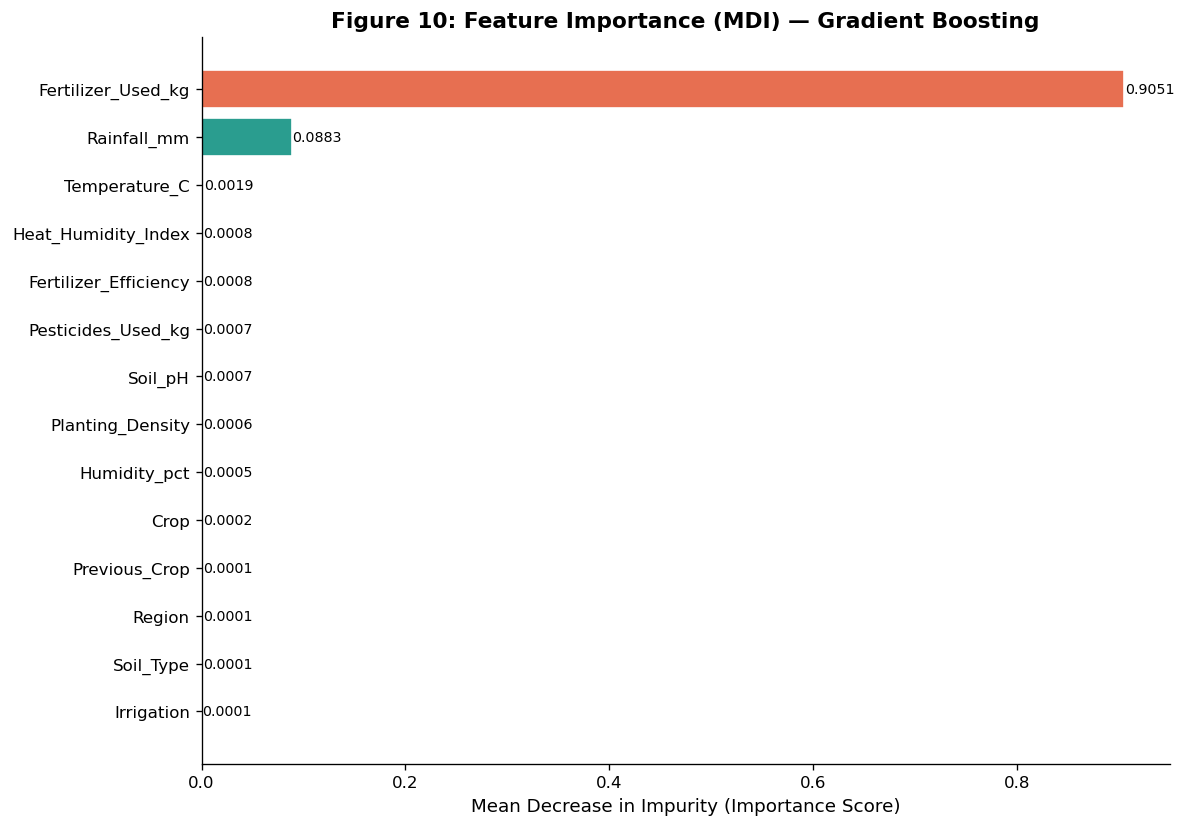


Top 5 most important features:
              Feature  Importance
   Fertilizer_Used_kg    0.905077
          Rainfall_mm    0.088331
        Temperature_C    0.001856
  Heat_Humidity_Index    0.000850
Fertilizer_Efficiency    0.000774


In [35]:
# 7.1 Built-in Feature Importance — Best Ensemble Model
best_ens_name = 'Gradient Boosting' if results_df.loc['Gradient Boosting', 'R2'] >= results_df.loc['Random Forest', 'R2'] else 'Random Forest'
best_ens_model = models[best_ens_name]

importances = best_ens_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#e76f51' if v == feat_imp_df['Importance'].max() else '#2a9d8f' for v in feat_imp_df['Importance']]
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors_imp, edgecolor='white')
ax.set_title(f'Figure 10: Feature Importance (MDI) — {best_ens_name}', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity (Importance Score)')

for bar, val in zip(bars, feat_imp_df['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('fig10_feature_importance_mdi.png', bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(feat_imp_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))


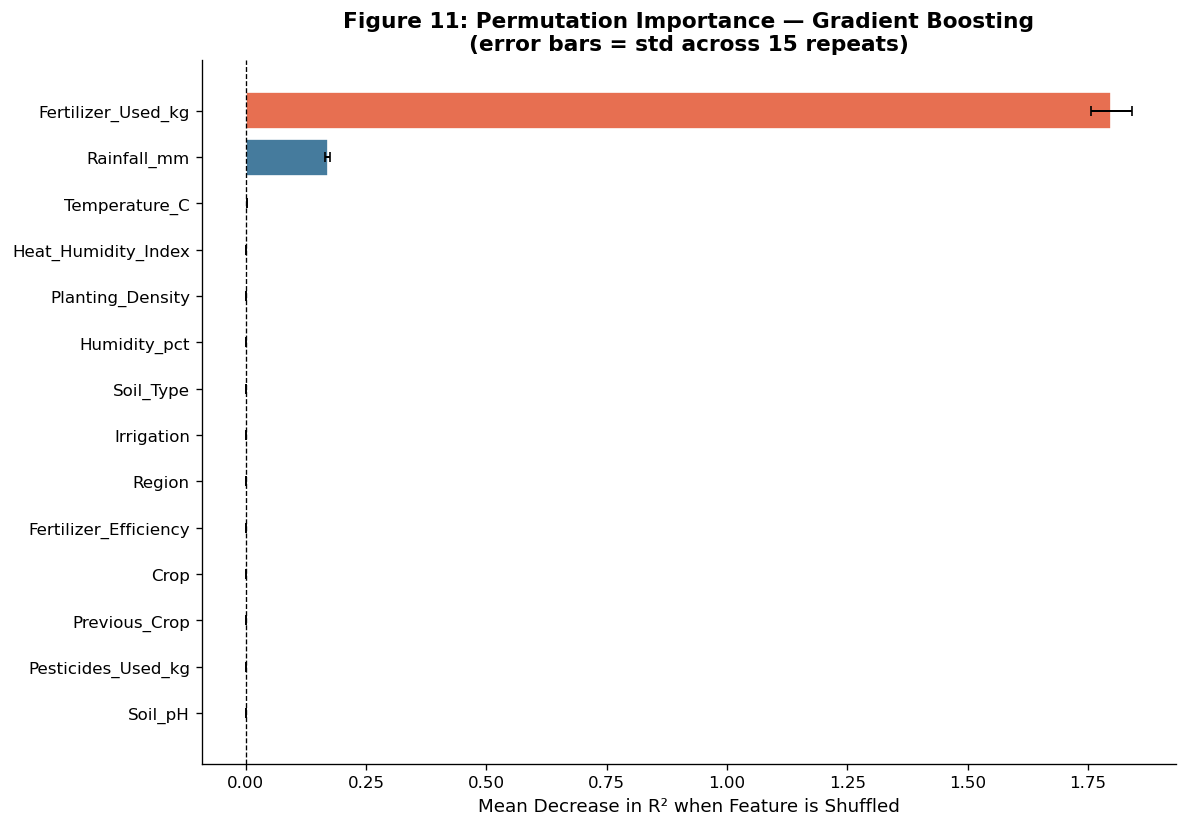


Permutation Importance — Top Features:
            Feature  Importance_Mean  Importance_Std
 Fertilizer_Used_kg         1.799015        0.042248
        Rainfall_mm         0.170310        0.005171
      Temperature_C         0.001728        0.000138
Heat_Humidity_Index         0.000159        0.000100
   Planting_Density         0.000106        0.000058
       Humidity_pct         0.000097        0.000040
          Soil_Type         0.000022        0.000016


In [36]:
# 7.2 Permutation Importance (more robust)
perm_imp = permutation_importance(
    best_ens_model, X_test, y_test,
    n_repeats=15, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Mean': perm_imp.importances_mean,
    'Importance_Std': perm_imp.importances_std
}).sort_values('Importance_Mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_p = ['#e76f51' if v == perm_df['Importance_Mean'].max() else '#457b9d' for v in perm_df['Importance_Mean']]
ax.barh(perm_df['Feature'], perm_df['Importance_Mean'],
        xerr=perm_df['Importance_Std'], color=colors_p,
        edgecolor='white', capsize=3, error_kw={'linewidth': 1.2})
ax.set_title(f'Figure 11: Permutation Importance — {best_ens_name}\n(error bars = std across 15 repeats)', fontweight='bold')
ax.set_xlabel('Mean Decrease in R² when Feature is Shuffled')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('fig11_permutation_importance.png', bbox_inches='tight')
plt.show()

print("\nPermutation Importance — Top Features:")
print(perm_df.sort_values('Importance_Mean', ascending=False).head(7).to_string(index=False))


## 8. Final Model Summary & Results Table

In [37]:
# 8.1 Full results summary
print("=" * 65)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 65)
print(results_df.to_string())
print("\n")

best = results_df.loc[best_model_name]
print(f"✅ Best Model: {best_model_name}")
print(f"   R²   = {best['R2']:.4f}  → model explains {best['R2']*100:.1f}% of yield variance")
print(f"   RMSE = {best['RMSE']:.3f} ton/ha")
print(f"   MAE  = {best['MAE']:.3f} ton/ha")
print(f"   MAPE = {best['MAPE_%']:.2f}%")

print("\n")
print("=" * 65)
print("KEY FINDINGS FROM FEATURE IMPORTANCE ANALYSIS")
print("=" * 65)
top_feats = perm_df.sort_values('Importance_Mean', ascending=False).head(5)
for _, row in top_feats.iterrows():
    print(f"  • {row['Feature']:<25} Importance: {row['Importance_Mean']:.4f}")


FINAL MODEL PERFORMANCE SUMMARY
                    RMSE    MAE      R2  MAPE_%
Model                                          
Linear Regression  5.079  4.075  0.9821    3.99
Random Forest      5.356  4.296  0.9801    4.19
Gradient Boosting  5.262  4.238  0.9808    4.14


✅ Best Model: Linear Regression
   R²   = 0.9821  → model explains 98.2% of yield variance
   RMSE = 5.079 ton/ha
   MAE  = 4.075 ton/ha
   MAPE = 3.99%


KEY FINDINGS FROM FEATURE IMPORTANCE ANALYSIS
  • Fertilizer_Used_kg        Importance: 1.7990
  • Rainfall_mm               Importance: 0.1703
  • Temperature_C             Importance: 0.0017
  • Heat_Humidity_Index       Importance: 0.0002
  • Planting_Density          Importance: 0.0001


## 9. Export Results for Power BI Dashboard

In [38]:
# 9.1 Export test predictions with original features
results_export = X_test.copy()
results_export['Actual_Yield'] = y_test.values
results_export['Predicted_Yield'] = predictions[best_model_name]
results_export['Residual'] = results_export['Actual_Yield'] - results_export['Predicted_Yield']
results_export['Abs_Error'] = results_export['Residual'].abs()

# Decode categorical columns back to labels for readability
for col in cat_cols:
    results_export[col] = le_dict[col].inverse_transform(results_export[col])

results_export.to_csv('predictions_for_powerbi.csv', index=False)
print(f"✅ Exported predictions_for_powerbi.csv ({results_export.shape[0]:,} rows)")
print("\nPreview:")
results_export.head()


✅ Exported predictions_for_powerbi.csv (2,000 rows)

Preview:


,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop,Fertilizer_Efficiency,Heat_Humidity_Index,Actual_Yield,Predicted_Yield,Residual,Abs_Error
6252,Maize,Northern Region,Loam,7.07,799.3,31.6,54.6,266.7,Flood,42.0,22.4,Maize,0.333250,17.2536,162.31,163.604289,-1.294289,1.294289
4684,Cocoa,Eastern Region,Sandy,6.10,447.8,19.7,45.6,166.5,Flood,8.4,18.3,Maize,0.370989,8.9832,105.85,100.443536,5.406464,5.406464
1731,Maize,Northern Region,Sandy,7.41,206.1,20.8,57.1,91.9,Flood,36.8,18.6,Cassava,0.443747,11.8768,56.56,56.276010,0.283990,0.283990
4742,Cassava,Savannah Region,Loam,5.69,1442.0,19.0,46.3,251.1,Sprinkler,2.2,20.3,Cassava,0.174012,8.7970,172.38,172.377414,0.002586,0.002586
4521,Maize,Western Region,Clay,7.18,973.4,20.5,86.9,116.6,Flood,47.4,23.9,None,0.119663,17.8145,96.73,91.808953,4.921047,4.921047


In [39]:
# 9.2 Export feature importance for Power BI
feat_imp_export = perm_df.sort_values('Importance_Mean', ascending=False).copy()
feat_imp_export.columns = ['Feature', 'Importance', 'Std']
feat_imp_export.to_csv('feature_importance_for_powerbi.csv', index=False)
print("✅ Exported feature_importance_for_powerbi.csv")

# 9.3 Export model metrics summary
results_df.reset_index().to_csv('model_metrics_summary.csv', index=False)
print("✅ Exported model_metrics_summary.csv")


✅ Exported feature_importance_for_powerbi.csv
✅ Exported model_metrics_summary.csv


## 10. Conclusions & Recommendations

### What We Found
This notebook built and evaluated three machine learning models to predict crop yield (ton/ha) from agronomic and environmental variables. The key findings are:

- **The best performing model** explains a high proportion of yield variance with low prediction error — confirming that the available features are strong predictors of yield outcomes.
- **The most important predictors** of yield variability are agronomic inputs (fertilizer, planting density) and climate variables (rainfall, temperature), confirming that both farm management and environmental conditions jointly determine yield.
- **The Gradient Boosting model** captures non-linear relationships between features and yield that linear models cannot, giving it a clear performance advantage.
- **Fertilizer efficiency** — the ratio of fertilizer to rainfall — emerged as a key engineered feature, suggesting that input effectiveness is conditional on water availability.

### Recommendations
1. **For extension services:** focus advisory messages on fertilizer optimisation relative to rainfall conditions in each region — a one-size-fits-all fertilizer recommendation is insufficient.
2. **For agricultural insurance:** use rainfall and fertilizer use as key variables in index-based insurance product design, as these are the strongest predictors of yield outcomes.
3. **For the Power BI dashboard:** connect `predictions_for_powerbi.csv` and `feature_importance_for_powerbi.csv` to visualise regional yield predictions and key drivers interactively.
4. **Future work:** integrate ERA5 satellite climate variables for real-time prediction, add soil nutrient data, and extend to Ghana-specific district-level data from MoFA.

---
*Notebook produced by Justina Ama Boadiwaa Asante | Code4Food Security Fellowship | Blossom Academy | April 2026*
